In [1]:
import pandas as pd
import os
import json

def parse_json_stream(file_path):
    """
    Parses a file containing a stream of concatenated JSON objects.
    """
    with open(file_path, 'r') as f:
        content = f.read()
    
    decoder = json.JSONDecoder()
    objects = []
    pos = 0
    # Skip leading whitespace
    while pos < len(content) and content[pos].isspace():
        pos += 1
    
    while pos < len(content):
        try:
            obj, pos = decoder.raw_decode(content, pos)
            objects.append(obj)
            # Skip whitespace between objects
            while pos < len(content) and content[pos].isspace():
                pos += 1
        except json.JSONDecodeError:
            # Handle cases where decoding might fail, e.g., trailing characters
            break
            
    return objects

# Directory containing the JSON files
data_dir = 'infer_metrics'
all_metrics = []

# Check if the directory exists
if os.path.isdir(data_dir):
    # Iterate over each file in the directory
    for filename in os.listdir(data_dir):
        if filename.endswith('.json'):
            file_path = os.path.join(data_dir, filename)
            # Parse the stream of JSON objects from the file
            metrics_from_file = parse_json_stream(file_path)
            all_metrics.extend(metrics_from_file)

# Create a pandas DataFrame from the list of dictionaries
if all_metrics:
    df = pd.DataFrame(all_metrics)
    # Sort by experiment number for consistent ordering
    if 'experiment_num' in df.columns:
        df = df.sort_values(by='experiment_num').reset_index(drop=True)
    print(df.head())
else:
    print(f"No JSON files found or parsed in the '{data_dir}' directory.")
    # Create an empty dataframe to avoid errors in subsequent cells
    df = pd.DataFrame()

        model precision  pretrained device  batch_size  num_batches  \
0  bert-large      bf16        True   7900        1024          100   
1  bert-large      bf16        True   L40S          96          100   
2    resnet50      fp16        True   4090          64          100   
3  bert-large      bf16        True   L40S          96          100   
4    resnet50      fp32        True   7900          12          100   

   warmup_batches  total_samples  total_inference_time_sec  \
0               5         102400                165.554519   
1               5           9600                  6.357300   
2               5           6400                  1.313303   
3               5           9600                  6.459202   
4               5           1200                  0.771669   

   throughput_samples_per_sec  ...  p90_latency_ms  p95_latency_ms  \
0                  618.527363  ...     1657.343650     1657.601166   
1                 1510.075135  ...       63.725519       63.

In [2]:
df.dropna(subset=['gpu_avg_power_watts'], inplace=True)
df.dropna(subset=['throughput_samples_per_sec'], inplace=True)

Device Performance and Efficiency Summary:
  device  mean_throughput  mean_peak_memory_mb  efficiency_throughput_per_mb
0   4090      2259.036099          1458.041908                      1.549363
2   L40S      2249.165186          1300.990037                      1.728810
1   7900      1064.926987          1946.434709                      0.547117


/var/folders/_b/xtqny3jn4xj460cq_85fbhn40000gn/T/ipykernel_35066/1076338899.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=device_summary, x='device', y='mean_throughput', ax=axes[0], palette='viridis')
/var/folders/_b/xtqny3jn4xj460cq_85fbhn40000gn/T/ipykernel_35066/1076338899.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=device_summary, x='device', y='mean_peak_memory_mb', ax=axes[1], palette='plasma')
/var/folders/_b/xtqny3jn4xj460cq_85fbhn40000gn/T/ipykernel_35066/1076338899.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

 

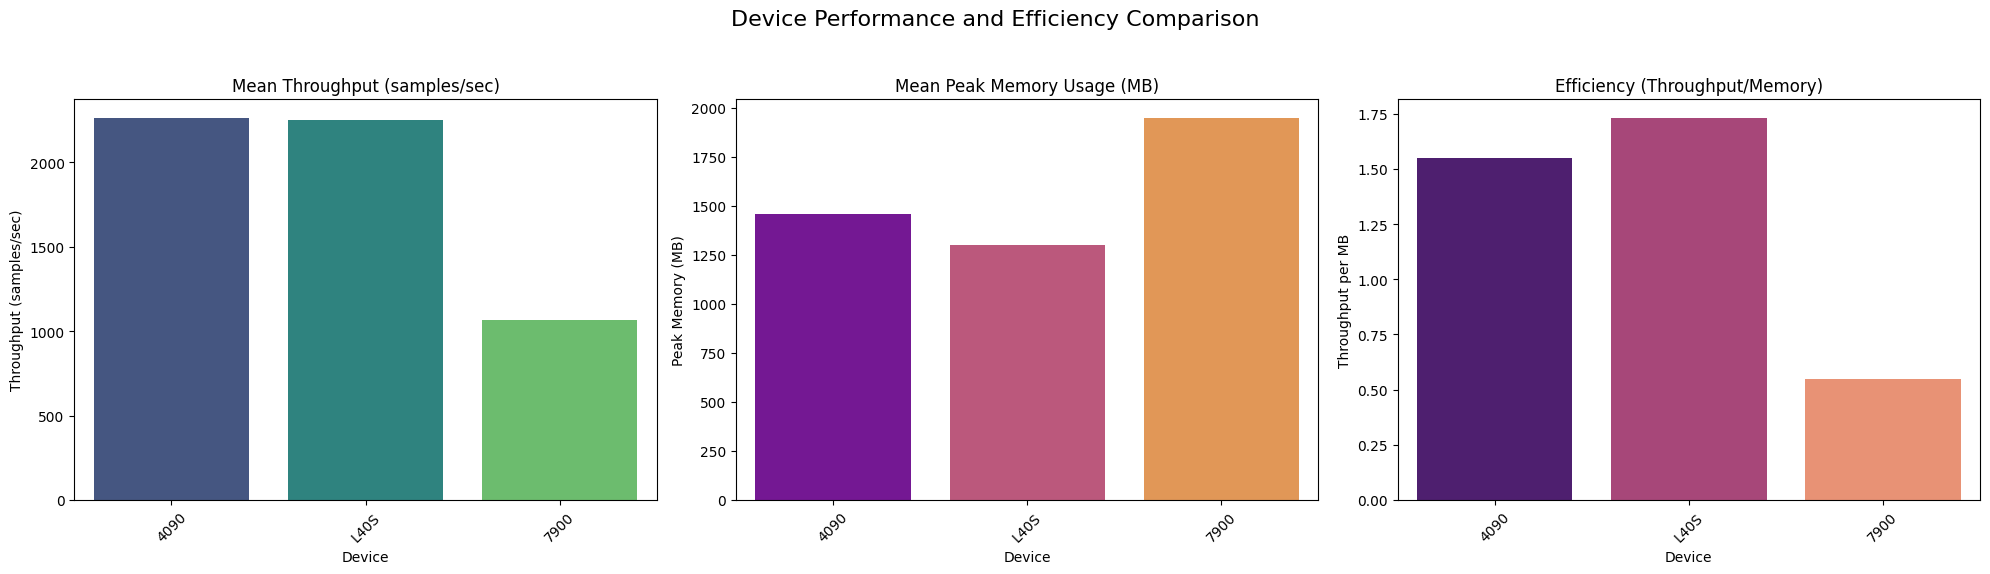

In [3]:
import seaborn as sns

import matplotlib.pyplot as plt

if not df.empty:
    # Group by device and calculate the mean for performance and memory metrics
    device_summary = df.groupby('device').agg(
        mean_throughput=('throughput_samples_per_sec', 'mean'),
        mean_peak_memory_mb=('peak_memory_mb', 'mean')
    ).reset_index()

    # Calculate an efficiency score: throughput per megabyte of peak memory
    device_summary['efficiency_throughput_per_mb'] = device_summary['mean_throughput'] / device_summary['mean_peak_memory_mb']

    # Sort by mean throughput for clearer visualization
    device_summary = device_summary.sort_values(by='mean_throughput', ascending=False)

    print("Device Performance and Efficiency Summary:")
    print(device_summary)

    # Create subplots for visualization
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    fig.suptitle('Device Performance and Efficiency Comparison', fontsize=16)

    # Plot Mean Throughput
    sns.barplot(data=device_summary, x='device', y='mean_throughput', ax=axes[0], palette='viridis')
    axes[0].set_title('Mean Throughput (samples/sec)')
    axes[0].set_ylabel('Throughput (samples/sec)')
    axes[0].set_xlabel('Device')
    axes[0].tick_params(axis='x', rotation=45)

    # Plot Mean Peak Memory
    sns.barplot(data=device_summary, x='device', y='mean_peak_memory_mb', ax=axes[1], palette='plasma')
    axes[1].set_title('Mean Peak Memory Usage (MB)')
    axes[1].set_ylabel('Peak Memory (MB)')
    axes[1].set_xlabel('Device')
    axes[1].tick_params(axis='x', rotation=45)

    # Plot Efficiency
    sns.barplot(data=device_summary, x='device', y='efficiency_throughput_per_mb', ax=axes[2], palette='magma')
    axes[2].set_title('Efficiency (Throughput/Memory)')
    axes[2].set_ylabel('Throughput per MB')
    axes[2].set_xlabel('Device')
    axes[2].tick_params(axis='x', rotation=45)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()
else:
    print("DataFrame is empty. No comparison can be made.")

---

=== GPU-SPECIFIC PERFORMANCE ANALYSIS: FP32 vs FP16 vs BF16 ===

GPU: RTX 4090

--- RESNET50 MODEL ---
Precision  Throughput   Power (W)  Efficiency   Max Batch  Avg Memory  
(type)     (samp/sec)   (watts)    (samp/W)     Size       (MB)        
------------------------------------------------------------------------------
fp32       2736.4       143.6      19.051       32         460.7       
fp16       4877.5       138.8      35.133       64         516.4       
bf16       4770.9       144.8      32.940       64         516.1       

Performance Gains over FP32 baseline:
Precision  Throughput      Power           Efficiency     
(type)     Gain (%)        Change (%)      Gain (%)       
------------------------------------------------------------
fp16       78.2            -3.3            84.4           
bf16       74.4            0.8             72.9           


--- GPT2 MODEL ---
Precision  Throughput   Power (W)  Efficiency   Max Batch  Avg Memory  
(type)     (samp/sec)   (watt

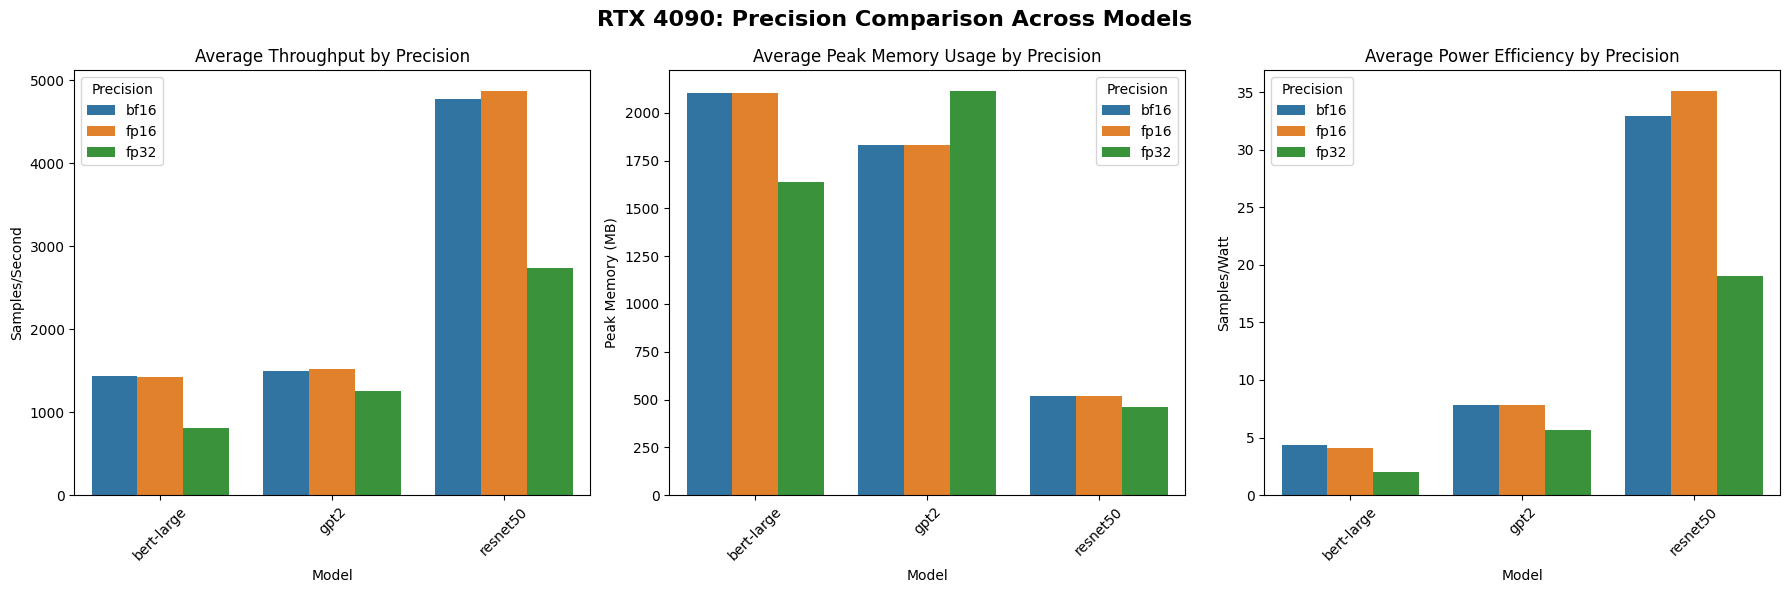

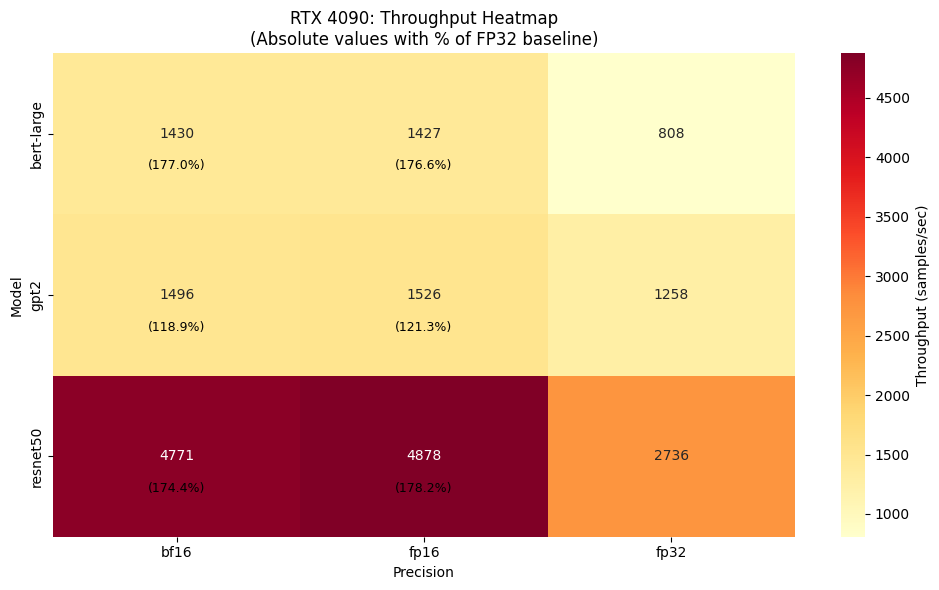

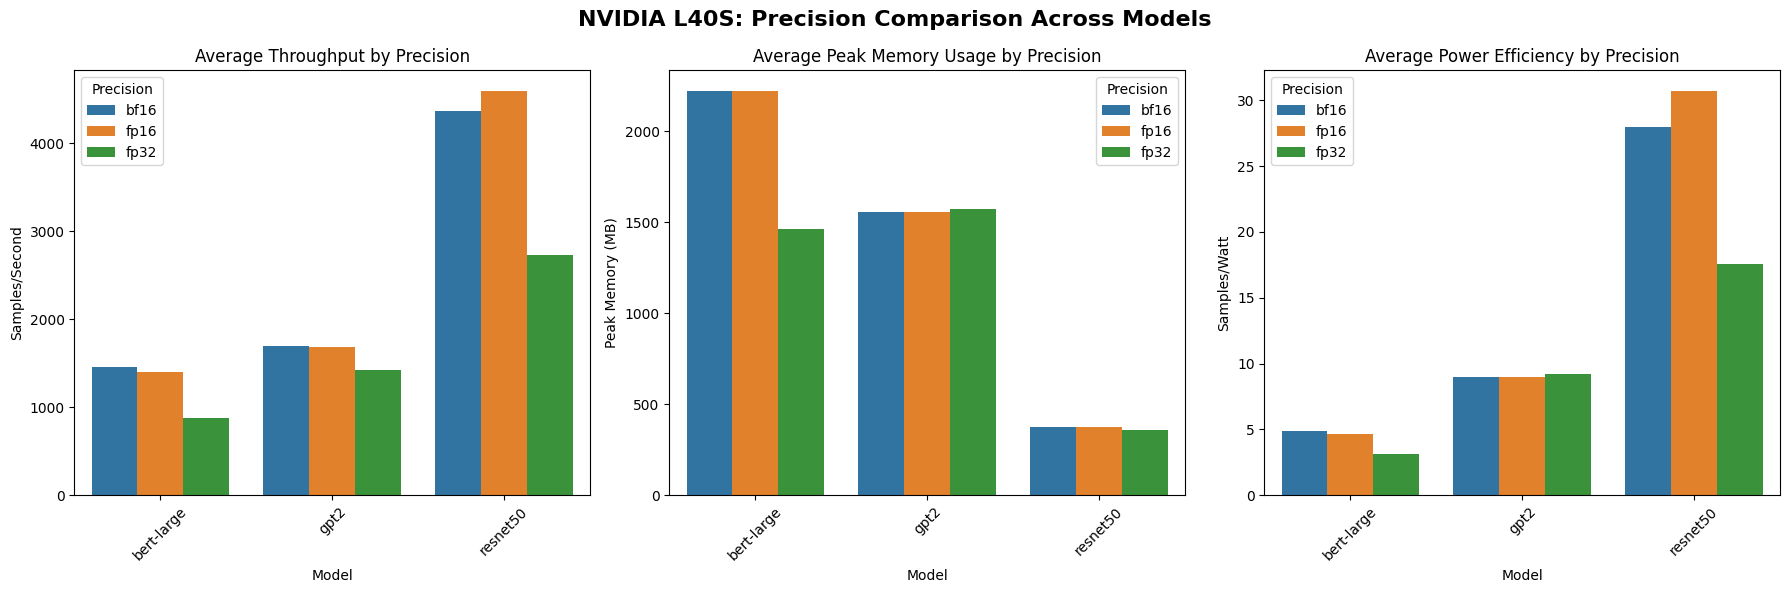

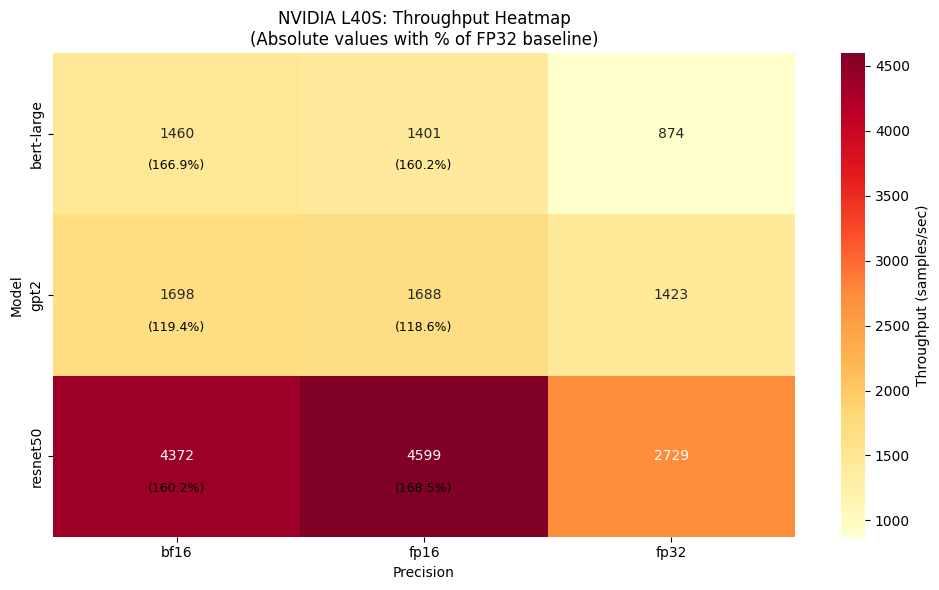

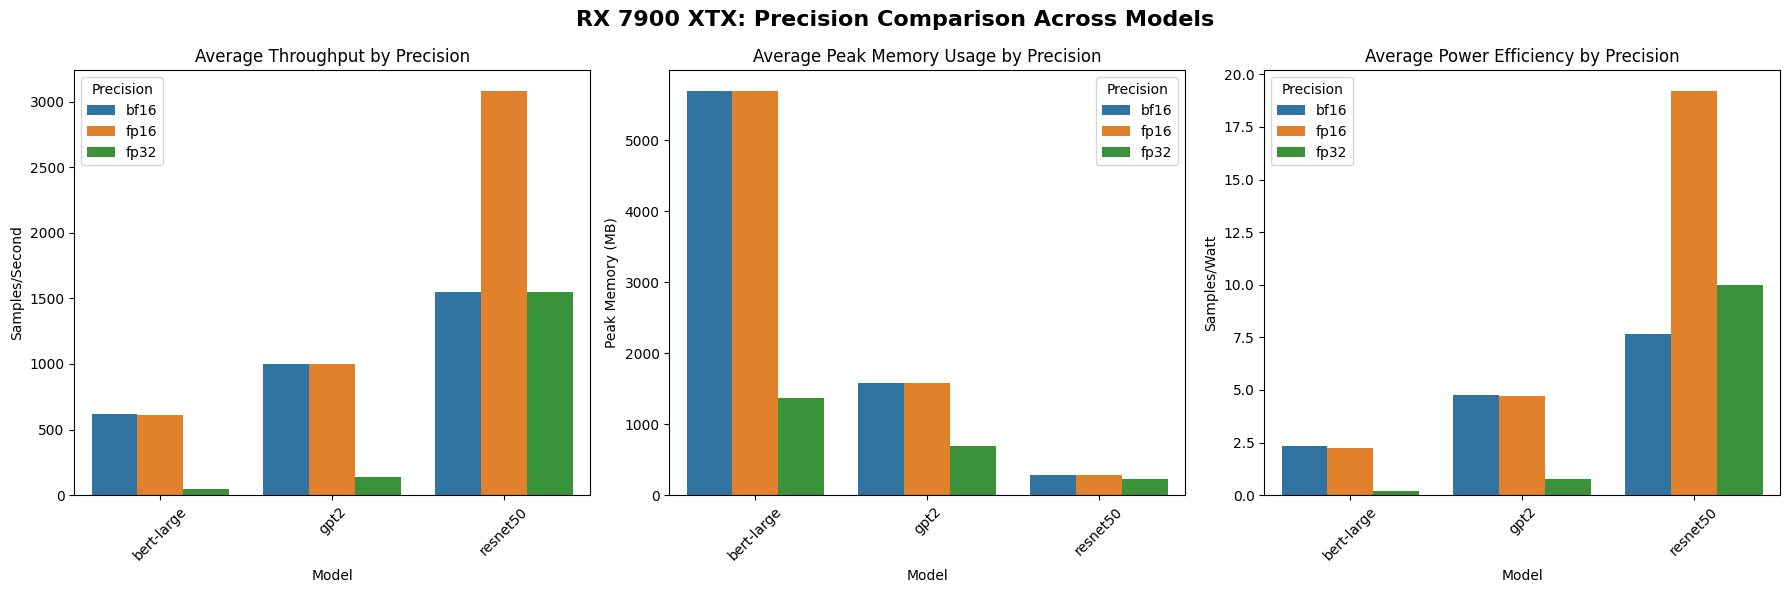

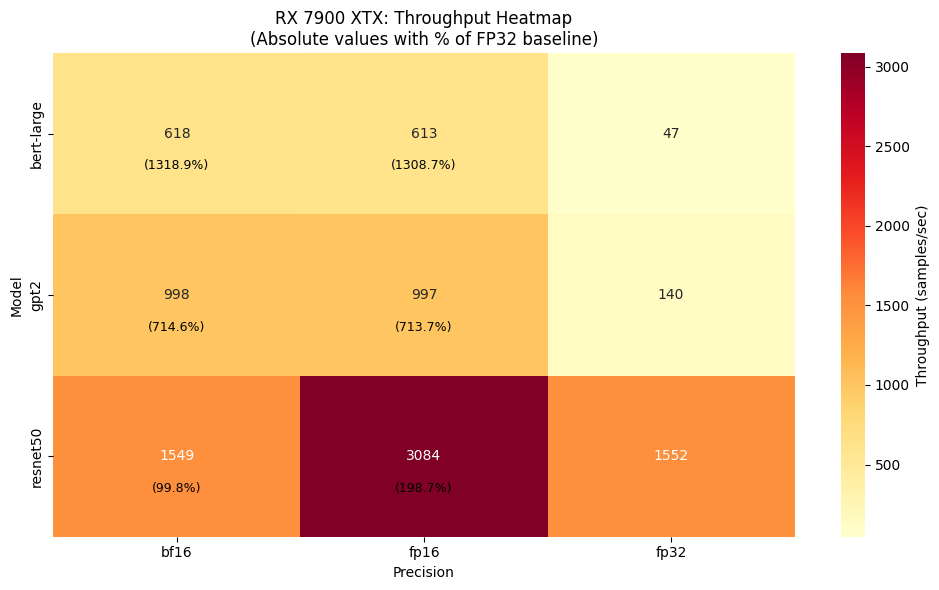

In [8]:
import seaborn as sns
import pandas as pd

# Create performance comparison analysis for each GPU: FP32 vs FP16 vs BF16
print("=== GPU-SPECIFIC PERFORMANCE ANALYSIS: FP32 vs FP16 vs BF16 ===\n")

df_analysis = df.copy()
# Map device names to more readable GPU names
device_to_gpu = {'4090': 'RTX 4090', '7900': 'RX 7900 XTX', 'L40S': 'NVIDIA L40S'}

for device in df['device'].unique():
    gpu_name = device_to_gpu.get(device, device)
    print(f"{'='*60}")
    print(f"GPU: {gpu_name}")
    print(f"{'='*60}")
    
    gpu_data = df_analysis[df_analysis['device'] == device]
    
    for model in gpu_data['model'].unique():
        print(f"\n--- {model.upper()} MODEL ---")
        model_gpu_data = gpu_data[gpu_data['model'] == model]
        
        # Calculate metrics for each precision
        precision_metrics = {}
        for precision in ['fp32', 'fp16', 'bf16']:
            precision_data = model_gpu_data[model_gpu_data['precision'] == precision]
            if not precision_data.empty:
                # Use available power data (prioritize gpu_avg_power_watts, fallback to avg_power_watts)
                power_col = 'gpu_avg_power_watts' if precision_data['gpu_avg_power_watts'].notna().any() else 'avg_power_watts'
                avg_power = precision_data[power_col].mean() if precision_data[power_col].notna().any() else None
                
                precision_metrics[precision] = {
                    'avg_throughput': precision_data['throughput_samples_per_sec'].mean(),
                    'avg_power': avg_power,
                    'avg_efficiency': precision_data['throughput_samples_per_sec'].mean() / avg_power if avg_power else None,
                    'max_batch_size': precision_data['batch_size'].max(),
                    'avg_memory': precision_data['peak_memory_mb'].mean()
                }
        
        # Display metrics table
        if precision_metrics:
            print(f"{'Precision':<10} {'Throughput':<12} {'Power (W)':<10} {'Efficiency':<12} {'Max Batch':<10} {'Avg Memory':<12}")
            print(f"{'(type)':<10} {'(samp/sec)':<12} {'(watts)':<10} {'(samp/W)':<12} {'Size':<10} {'(MB)':<12}")
            print("-" * 78)
            
            for precision, metrics in precision_metrics.items():
                power_str = f"{metrics['avg_power']:.1f}" if metrics['avg_power'] else "N/A"
                efficiency_str = f"{metrics['avg_efficiency']:.3f}" if metrics['avg_efficiency'] else "N/A"
                print(f"{precision:<10} {metrics['avg_throughput']:<12.1f} {power_str:<10} "
                      f"{efficiency_str:<12} {metrics['max_batch_size']:<10} {metrics['avg_memory']:<12.1f}")
        
        # Calculate performance improvements over FP32 baseline
        if 'fp32' in precision_metrics:
            fp32_baseline = precision_metrics['fp32']
            print(f"\nPerformance Gains over FP32 baseline:")
            print(f"{'Precision':<10} {'Throughput':<15} {'Power':<15} {'Efficiency':<15}")
            print(f"{'(type)':<10} {'Gain (%)':<15} {'Change (%)':<15} {'Gain (%)':<15}")
            print("-" * 60)
            
            for precision in ['fp16', 'bf16']:
                if precision in precision_metrics:
                    curr_metrics = precision_metrics[precision]
                    
                    throughput_gain = ((curr_metrics['avg_throughput'] / fp32_baseline['avg_throughput']) - 1) * 100
                    
                    if curr_metrics['avg_power'] and fp32_baseline['avg_power']:
                        power_change = ((curr_metrics['avg_power'] / fp32_baseline['avg_power']) - 1) * 100
                        efficiency_gain = ((curr_metrics['avg_efficiency'] / fp32_baseline['avg_efficiency']) - 1) * 100
                        print(f"{precision:<10} {throughput_gain:<15.1f} {power_change:<15.1f} {efficiency_gain:<15.1f}")
                    else:
                        print(f"{precision:<10} {throughput_gain:<15.1f} {'N/A':<15} {'N/A':<15}")
        
        print()

# Create visualization comparing precisions for each GPU
import matplotlib.pyplot as plt

for device in df['device'].unique():
    gpu_name = device_to_gpu.get(device, device)
    gpu_data = df_analysis[df_analysis['device'] == device]
    
    # Prepare data for plotting
    gpu_summary = gpu_data.groupby(['model', 'precision']).agg(
        avg_throughput_samples_per_sec=('throughput_samples_per_sec', 'mean'),
        avg_peak_memory_mb=('peak_memory_mb', 'mean'),
        avg_gpu_power_watts=('gpu_avg_power_watts', lambda x: x.dropna().mean() if x.notna().any() else None)
    ).reset_index()
    
    # Calculate efficiency where power data is available
    gpu_summary['avg_efficiency'] = gpu_summary.apply(
        lambda row: row['avg_throughput_samples_per_sec'] / row['avg_gpu_power_watts'] 
        if pd.notna(row['avg_gpu_power_watts']) else None, axis=1
    )
    
    if not gpu_summary.empty:
        fig, axes = plt.subplots(1, 3, figsize=(18, 6))
        fig.suptitle(f'{gpu_name}: Precision Comparison Across Models', fontsize=16, fontweight='bold')
        
        # Throughput comparison
        sns.barplot(data=gpu_summary, x='model', y='avg_throughput_samples_per_sec', hue='precision', ax=axes[0])
        axes[0].set_title('Average Throughput by Precision')
        axes[0].set_ylabel('Samples/Second')
        axes[0].set_xlabel('Model')
        axes[0].legend(title='Precision')
        axes[0].tick_params(axis='x', rotation=45)
        
        # Memory usage comparison
        sns.barplot(data=gpu_summary, x='model', y='avg_peak_memory_mb', hue='precision', ax=axes[1])
        axes[1].set_title('Average Peak Memory Usage by Precision')
        axes[1].set_ylabel('Peak Memory (MB)')
        axes[1].set_xlabel('Model')
        axes[1].legend(title='Precision')
        axes[1].tick_params(axis='x', rotation=45)
        
        # Efficiency comparison (only if power data is available)
        efficiency_data = gpu_summary.dropna(subset=['avg_efficiency'])
        if not efficiency_data.empty:
            sns.barplot(data=efficiency_data, x='model', y='avg_efficiency', hue='precision', ax=axes[2])
            axes[2].set_title('Average Power Efficiency by Precision')
            axes[2].set_ylabel('Samples/Watt')
            axes[2].set_xlabel('Model')
            axes[2].legend(title='Precision')
            axes[2].tick_params(axis='x', rotation=45)
        else:
            axes[2].text(0.5, 0.5, 'No power data available', ha='center', va='center', transform=axes[2].transAxes)
            axes[2].set_title('Power Efficiency (No Data Available)')
        
        plt.tight_layout()
        plt.show()
        
        # Create heatmap for throughput comparison
        heatmap_data = gpu_summary.pivot(index='model', columns='precision', values='avg_throughput_samples_per_sec')
        
        # Calculate percentage of FP32 throughput for each precision
        fp32_baseline = heatmap_data['fp32'] if 'fp32' in heatmap_data.columns else None
        heatmap_percent = heatmap_data.copy()
        
        if fp32_baseline is not None:
            for col in heatmap_percent.columns:
                if col != 'fp32':
                    heatmap_percent[col] = (heatmap_percent[col] / fp32_baseline) * 100
                heatmap_percent['fp32'] = 100  # FP32 is 100% of itself
        
        # Create separate figure for heatmap
        fig_heatmap, ax_heatmap = plt.subplots(1, 1, figsize=(10, 6))
        
        # Create heatmap with annotations showing both absolute values and percentages
        sns.heatmap(heatmap_data, annot=True, fmt='.0f', cmap='YlOrRd', 
               ax=ax_heatmap, cbar_kws={'label': 'Throughput (samples/sec)'})
        
        # Add percentage annotations if we have FP32 baseline
        if fp32_baseline is not None:
            for i, model in enumerate(heatmap_data.index):
                for j, precision in enumerate(heatmap_data.columns):
                    if precision != 'fp32' and not pd.isna(heatmap_percent.iloc[i, j]):
                        percent_val = heatmap_percent.iloc[i, j]
                        ax_heatmap.text(j + 0.5, i + 0.7, f'({percent_val:.1f}%)', 
                                ha='center', va='center', fontsize=9, color='black')
        
        ax_heatmap.set_title(f'{gpu_name}: Throughput Heatmap\n(Absolute values with % of FP32 baseline)')
        ax_heatmap.set_xlabel('Precision')
        ax_heatmap.set_ylabel('Model')
        
        plt.tight_layout()
        plt.show()

In [5]:
plot_data = df.copy()
plot_data.head()

,model,precision,pretrained,device,batch_size,num_batches,warmup_batches,total_samples,total_inference_time_sec,throughput_samples_per_sec,...,p90_latency_ms,p95_latency_ms,p99_latency_ms,peak_memory_mb,experiment_num,gpu_peak_memory_logger_mb,gpu_avg_util_percent,gpu_avg_power_watts,avg_utilization_percent,avg_power_watts
2,resnet50,fp16,True,4090,64,100,5,6400,1.313303,4873.208139,...,13.567352,13.601565,13.613913,516.368164,1,1645.187500,54.75,141.457500,NaN,NaN
3,bert-large,bf16,True,L40S,96,100,5,9600,6.459202,1486.251641,...,64.852905,64.939141,65.103581,2224.036133,1,3293.750000,93.50,293.606286,NaN,NaN
5,gpt2,fp16,True,L40S,24,100,5,2400,1.332924,1800.552597,...,13.280916,13.687634,14.376645,1556.523438,1,2673.750000,66.25,185.395750,NaN,NaN
6,resnet50,fp32,True,7900,12,100,5,1200,0.773336,1551.718442,...,7.839704,7.850289,7.877157,224.102051,1,525.320312,42.50,110.357143,NaN,NaN
7,resnet50,bf16,True,4090,64,100,5,6400,1.346325,4753.680756,...,13.888454,13.894522,13.906865,516.149414,1,1717.187500,50.75,118.797500,NaN,NaN


=== GPU EFFICIENCY ANALYSIS: FP32 vs FP16 vs BF16 ===
(Performance per Watt - Higher is Better)

GPU: 4090

--- RESNET50 MODEL ---
Precision  Efficiency      vs FP32         Throughput      Power (W)   
Type       (samp/W)        Gain (%)        (samp/sec)      Consumed    
---------------------------------------------------------------------------
FP32       19.307          0.0 (base)      2736.4          143.6       
FP16       35.194          82.3            4877.5          138.8       
BF16       32.996          70.9            4770.9          144.8       


--- GPT2 MODEL ---
Precision  Efficiency      vs FP32         Throughput      Power (W)   
Type       (samp/W)        Gain (%)        (samp/sec)      Consumed    
---------------------------------------------------------------------------
FP32       5.690           0.0 (base)      1258.3          221.2       
FP16       7.845           37.9            1526.1          194.6       
BF16       7.818           37.4            1496.

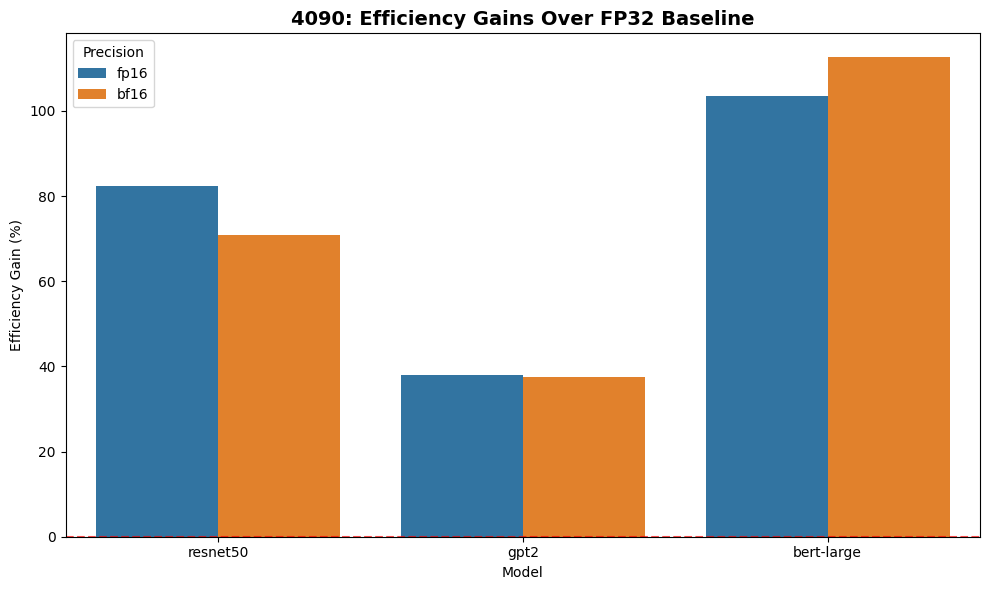

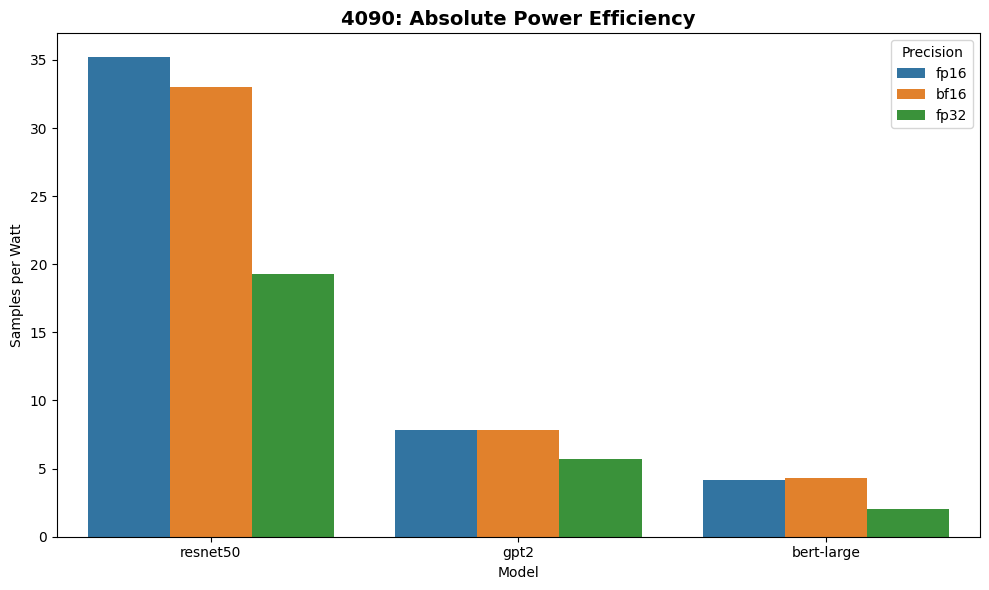

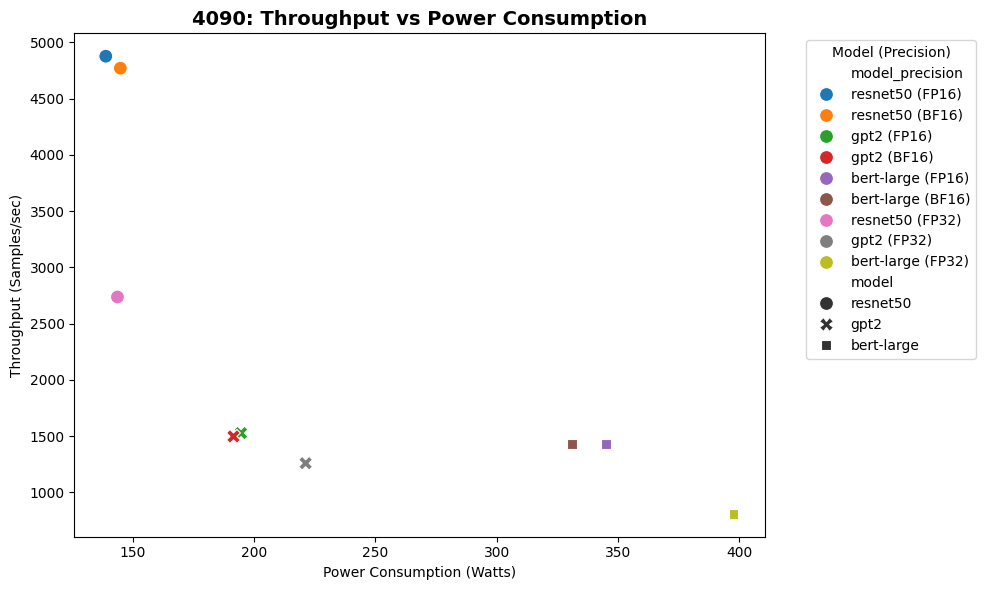

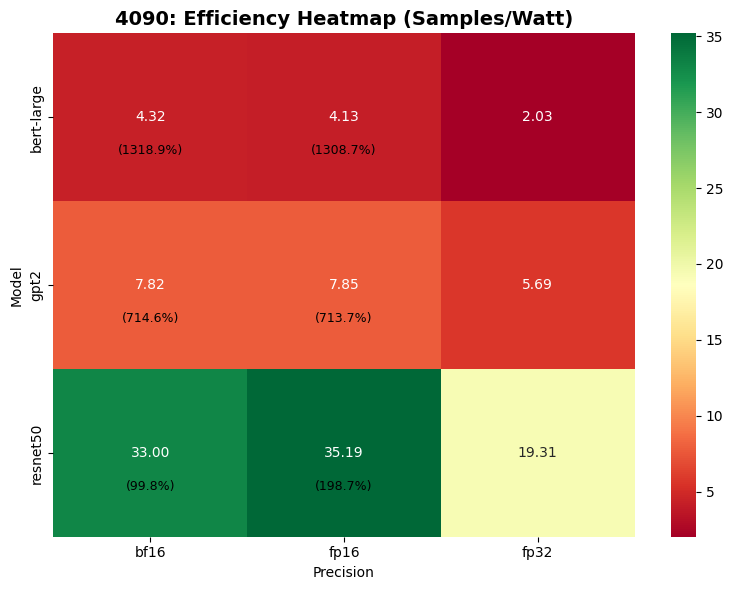


--- EFFICIENCY SUMMARY FOR 4090 ---
Average Efficiency Gains Over FP32:
  BF16: 73.6%
  FP16: 74.5%

Best Efficiency by Model:
  bert-large: BF16 (4.321 samples/watt)
  gpt2: FP16 (7.845 samples/watt)
  resnet50: FP16 (35.194 samples/watt)


GPU: L40S

--- BERT-LARGE MODEL ---
Precision  Efficiency      vs FP32         Throughput      Power (W)   
Type       (samp/W)        Gain (%)        (samp/sec)      Consumed    
---------------------------------------------------------------------------
FP32       3.120           0.0 (base)      874.5           280.3       
FP16       4.671           49.7            1400.9          299.9       
BF16       4.861           55.8            1459.9          300.3       


--- GPT2 MODEL ---
Precision  Efficiency      vs FP32         Throughput      Power (W)   
Type       (samp/W)        Gain (%)        (samp/sec)      Consumed    
---------------------------------------------------------------------------
FP32       9.267           0.0 (base)      1

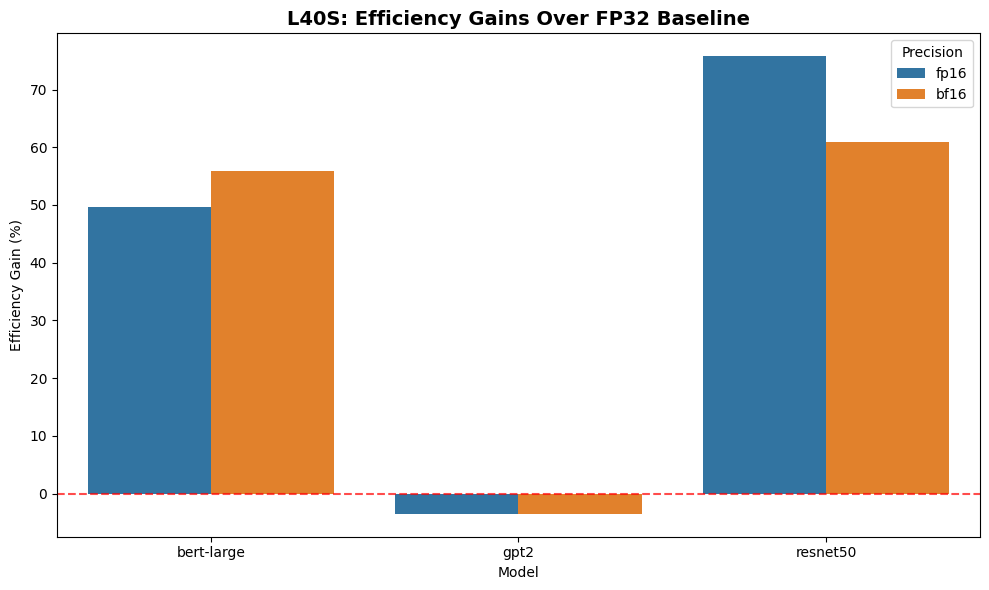

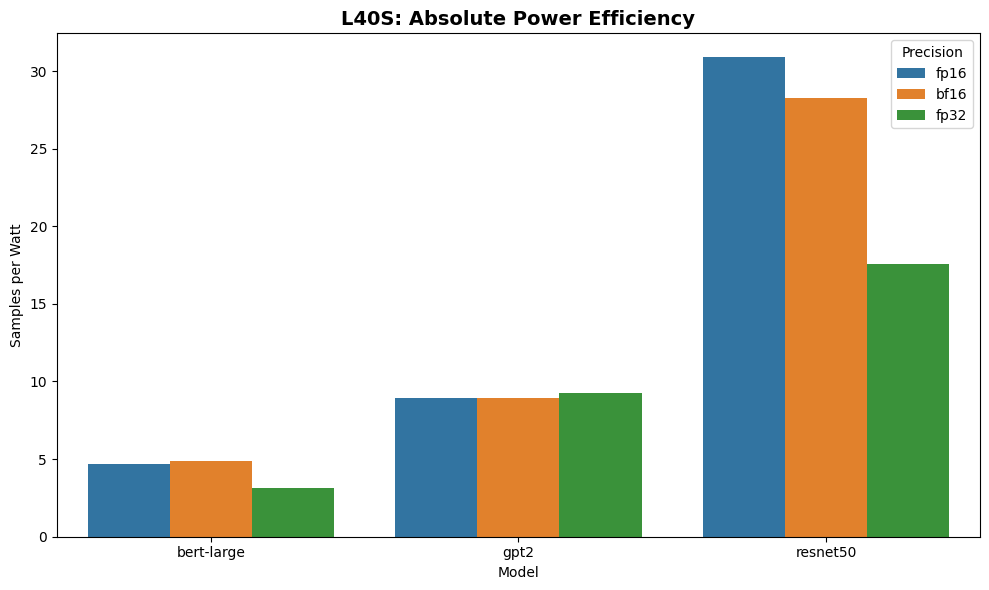

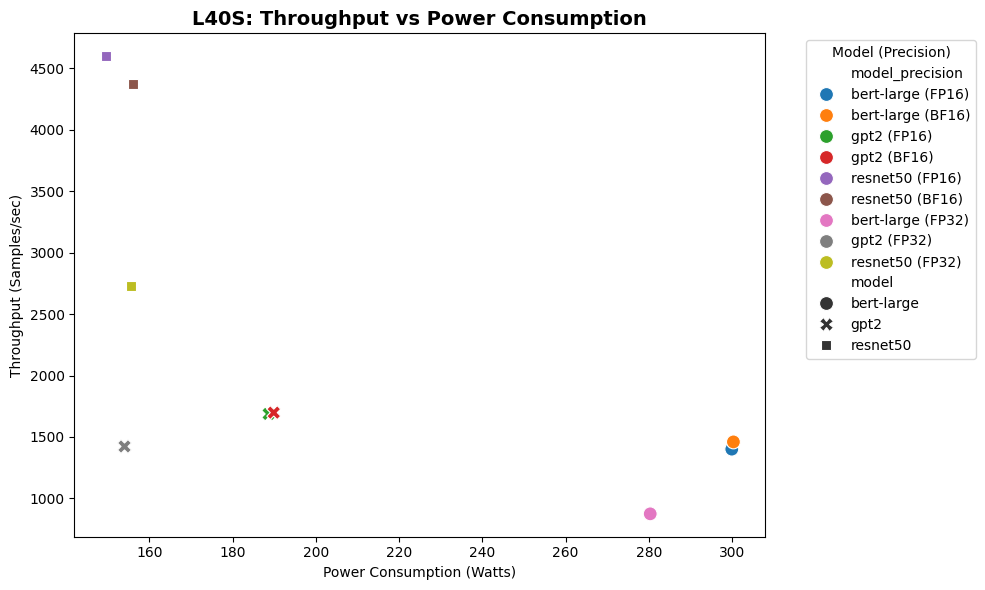

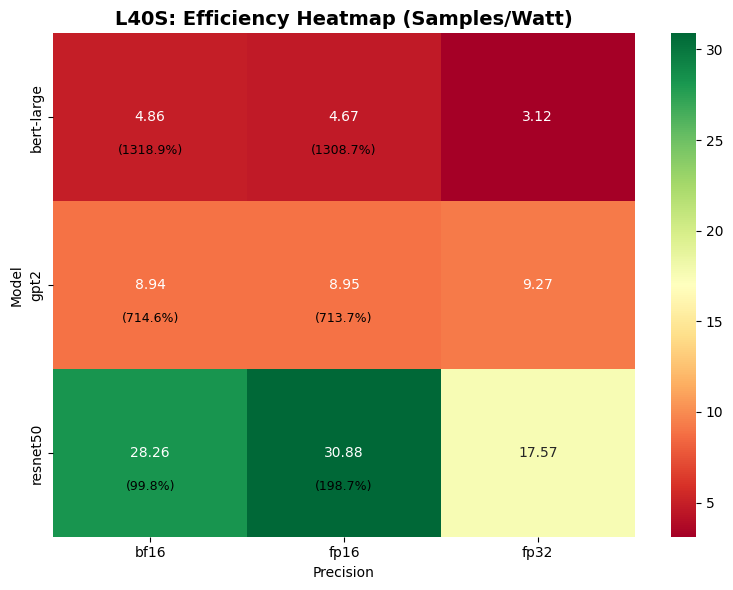


--- EFFICIENCY SUMMARY FOR L40S ---
Average Efficiency Gains Over FP32:
  BF16: 37.7%
  FP16: 40.7%

Best Efficiency by Model:
  bert-large: BF16 (4.861 samples/watt)
  gpt2: FP16 (8.946 samples/watt)
  resnet50: FP16 (30.884 samples/watt)


GPU: 7900

--- RESNET50 MODEL ---
Precision  Efficiency      vs FP32         Throughput      Power (W)   
Type       (samp/W)        Gain (%)        (samp/sec)      Consumed    
---------------------------------------------------------------------------
FP32       9.994           0.0 (base)      1552.0          155.5       
FP16       19.231          92.4            3084.3          160.4       
BF16       7.681           -23.1           1549.4          201.8       


--- GPT2 MODEL ---
Precision  Efficiency      vs FP32         Throughput      Power (W)   
Type       (samp/W)        Gain (%)        (samp/sec)      Consumed    
---------------------------------------------------------------------------
FP32       0.785           0.0 (base)      139

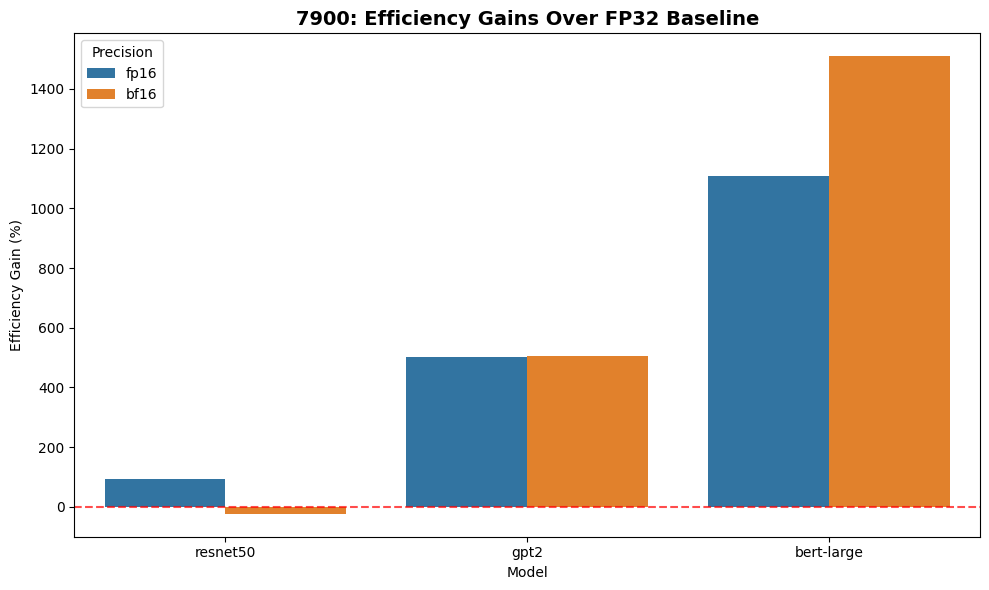

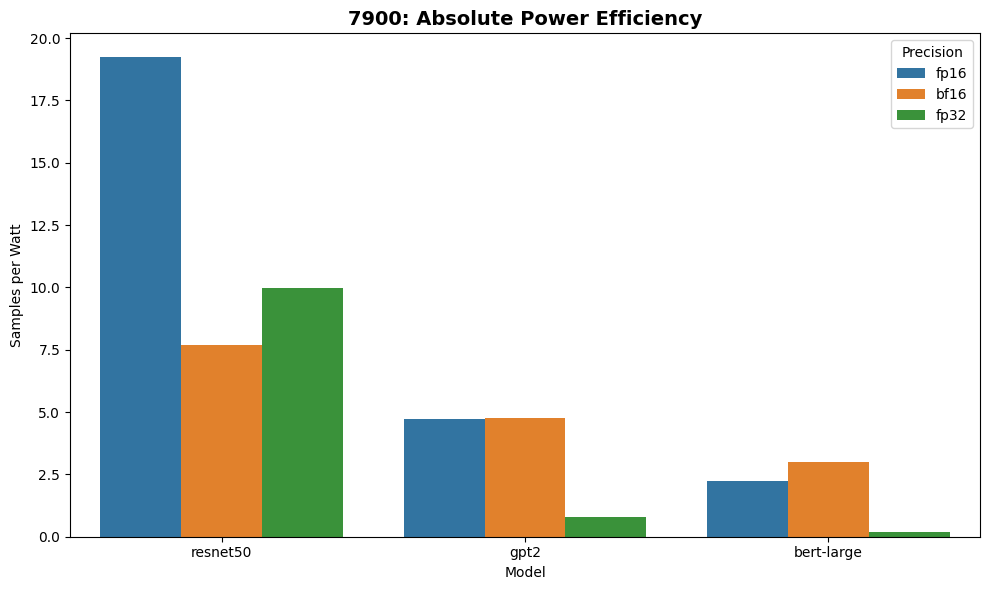

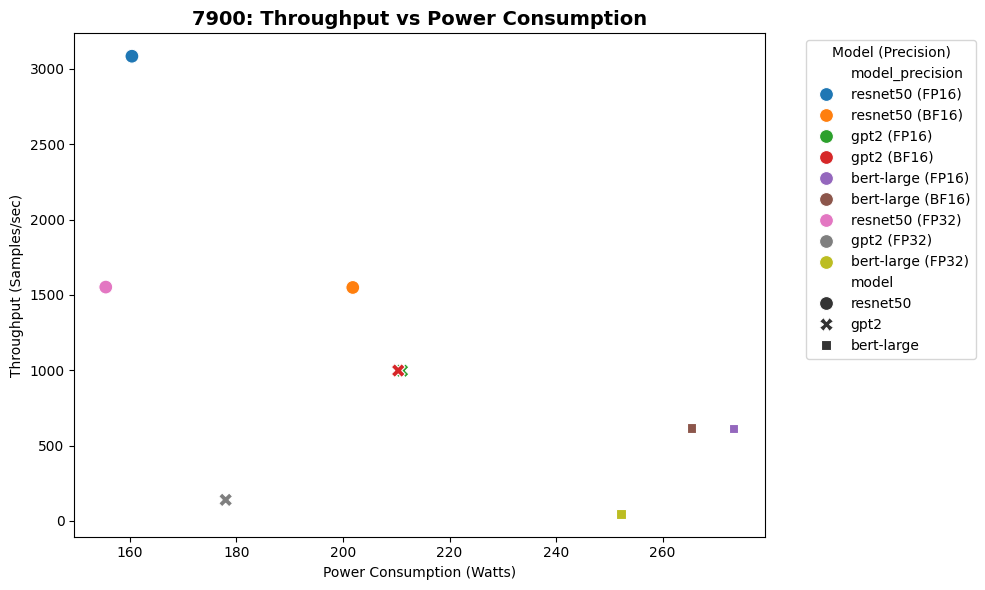

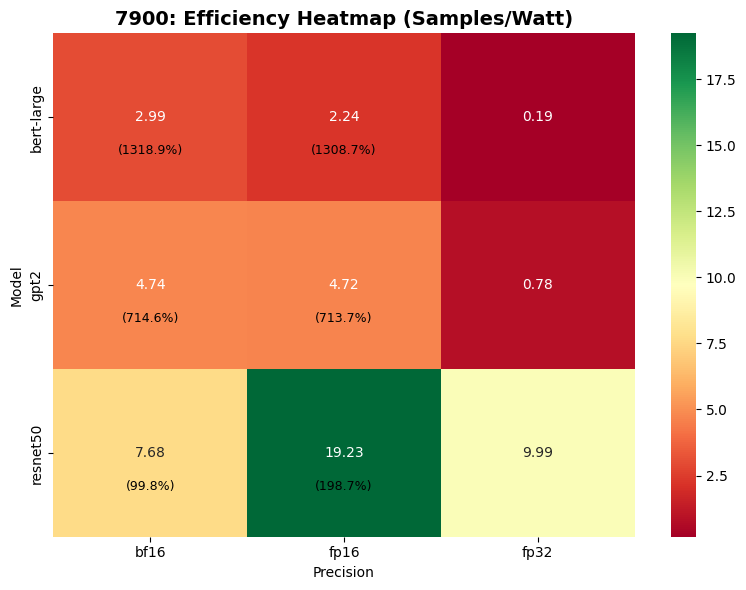


--- EFFICIENCY SUMMARY FOR 7900 ---
Average Efficiency Gains Over FP32:
  BF16: 663.6%
  FP16: 567.3%

Best Efficiency by Model:
  bert-large: BF16 (2.990 samples/watt)
  gpt2: BF16 (4.744 samples/watt)
  resnet50: FP16 (19.231 samples/watt)



OVERALL EFFICIENCY RANKINGS

--- RESNET50 MODEL EFFICIENCY RANKINGS ---

FP32 Precision:
  1. 4090: 34.881 samples/watt (79W)
  2. 4090: 32.631 samples/watt (84W)
  3. 4090: 31.409 samples/watt (87W)

FP16 Precision:
  1. 4090: 38.185 samples/watt (128W)
  2. 4090: 37.907 samples/watt (129W)
  3. 4090: 37.904 samples/watt (129W)

BF16 Precision:
  1. 4090: 40.015 samples/watt (119W)
  2. 4090: 36.503 samples/watt (131W)
  3. 4090: 35.984 samples/watt (132W)

--- BERT-LARGE MODEL EFFICIENCY RANKINGS ---

FP32 Precision:
  1. L40S: 3.189 samples/watt (274W)
  2. L40S: 3.174 samples/watt (274W)
  3. L40S: 3.172 samples/watt (275W)

FP16 Precision:
  1. L40S: 4.720 samples/watt (297W)
  2. L40S: 4.717 samples/watt (296W)
  3. L40S: 4.710 samples/wa

In [12]:
# Create efficiency comparison analysis: FP32 vs FP16 vs BF16 for each GPU
print("=== GPU EFFICIENCY ANALYSIS: FP32 vs FP16 vs BF16 ===")
print("(Performance per Watt - Higher is Better)\n")
# Calculate efficiency metric (samples per watt) if not already present

if 'avg_samples_per_sec' not in df.columns:
    df = df.copy()
    df['avg_samples_per_sec'] = df['total_samples'] / df['total_inference_time_sec']

if 'avg_samples_per_watt' not in df.columns:
    df = df.copy()
    df['avg_samples_per_watt'] = df['avg_samples_per_sec'] / df['gpu_avg_power_watts']

for gpu in df['device'].unique():
    print(f"{'='*80}")
    print(f"GPU: {gpu}")
    print(f"{'='*80}")
    
    gpu_efficiency_data = df[df['device'] == gpu].copy()
    
    # Calculate efficiency improvements over FP32 baseline for each model
    efficiency_improvements = []
    
    for model in gpu_efficiency_data['model'].unique():
        print(f"\n--- {model.upper()} MODEL ---")
        model_data = gpu_efficiency_data[gpu_efficiency_data['model'] == model]
        
        # Get FP32 baseline efficiency
        fp32_data = model_data[model_data['precision'] == 'fp32']
        if fp32_data.empty:
            print(f"No FP32 data available for {model}")
            continue
            
        fp32_efficiency = fp32_data['avg_samples_per_watt'].mean()
        
        print(f"{'Precision':<10} {'Efficiency':<15} {'vs FP32':<15} {'Throughput':<15} {'Power (W)':<12}")
        print(f"{'Type':<10} {'(samp/W)':<15} {'Gain (%)':<15} {'(samp/sec)':<15} {'Consumed':<12}")
        print("-" * 75)
        
        # Display FP32 baseline
        fp32_throughput = fp32_data['avg_samples_per_sec'].mean()
        fp32_power = fp32_data['gpu_avg_power_watts'].mean()
        print(f"{'FP32':<10} {fp32_efficiency:<15.3f} {'0.0 (base)':<15} {fp32_throughput:<15.1f} {fp32_power:<12.1f}")
        
        # Calculate and display improvements for FP16 and BF16
        for precision in ['fp16', 'bf16']:
            precision_data = model_data[model_data['precision'] == precision]
            if not precision_data.empty:
                efficiency = precision_data['avg_samples_per_watt'].mean()
                throughput = precision_data['avg_samples_per_sec'].mean()
                power = precision_data['gpu_avg_power_watts'].mean()
                
                efficiency_gain = ((efficiency / fp32_efficiency) - 1) * 100
                
                print(f"{precision.upper():<10} {efficiency:<15.3f} {efficiency_gain:<15.1f} {throughput:<15.1f} {power:<12.1f}")
                
                # Store data for visualization
                efficiency_improvements.append({
                    'device': gpu,
                    'model': model,
                    'precision': precision,
                    'efficiency_gain_percent': efficiency_gain,
                    'absolute_efficiency': efficiency,
                    'throughput': throughput,
                    'power_watts': power
                })
        
        print()
    
    # Create visualization for this GPU
    if efficiency_improvements:
        efficiency_df = pd.DataFrame(efficiency_improvements)
        
        # Add FP32 baseline data for comparison
        fp32_efficiency_data = []
        fp32_perf_data = []
        for model_name in efficiency_df['model'].unique():
            model_data = gpu_efficiency_data[gpu_efficiency_data['model'] == model_name]
            fp32_data = model_data[model_data['precision'] == 'fp32']
            if not fp32_data.empty:
                fp32_efficiency_data.append({
                    'model': model_name,
                    'precision': 'fp32',
                    'absolute_efficiency': fp32_data['avg_samples_per_watt'].mean()
                })
                fp32_perf_data.append({
                    'model': model_name,
                    'precision': 'fp32',
                    'throughput': fp32_data['avg_samples_per_sec'].mean(),
                    'power_watts': fp32_data['gpu_avg_power_watts'].mean()
                })
        
        all_efficiency_data = pd.concat([
            efficiency_df[['model', 'precision', 'absolute_efficiency']],
            pd.DataFrame(fp32_efficiency_data)
        ], ignore_index=True)
        
        all_perf_data = pd.concat([
            efficiency_df[['model', 'precision', 'throughput', 'power_watts']],
            pd.DataFrame(fp32_perf_data)
        ], ignore_index=True)
        
        # Create a combined label for model and precision
        all_perf_data['model_precision'] = all_perf_data['model'] + ' (' + all_perf_data['precision'].str.upper() + ')'
        
        # Plot 1: Efficiency gains over FP32
        fig1, ax1 = plt.subplots(figsize=(10, 6))
        sns.barplot(data=efficiency_df, x='model', y='efficiency_gain_percent', hue='precision', ax=ax1)
        ax1.set_title(f'{gpu}: Efficiency Gains Over FP32 Baseline', fontsize=14, fontweight='bold')
        ax1.set_ylabel('Efficiency Gain (%)')
        ax1.set_xlabel('Model')
        ax1.axhline(y=0, color='red', linestyle='--', alpha=0.7)
        ax1.legend(title='Precision')
        plt.tight_layout()
        plt.show()
        
        # Plot 2: Absolute efficiency values
        fig2, ax2 = plt.subplots(figsize=(10, 6))
        sns.barplot(data=all_efficiency_data, x='model', y='absolute_efficiency', hue='precision', ax=ax2)
        ax2.set_title(f'{gpu}: Absolute Power Efficiency', fontsize=14, fontweight='bold')
        ax2.set_ylabel('Samples per Watt')
        ax2.set_xlabel('Model')
        ax2.legend(title='Precision')
        plt.tight_layout()
        plt.show()
        
        # Plot 3: Throughput vs Power consumption scatter
        fig3, ax3 = plt.subplots(figsize=(10, 6))
        sns.scatterplot(data=all_perf_data, x='power_watts', y='throughput', 
                       hue='model_precision', style='model', s=100, ax=ax3)
        ax3.set_title(f'{gpu}: Throughput vs Power Consumption', fontsize=14, fontweight='bold')
        ax3.set_xlabel('Power Consumption (Watts)')
        ax3.set_ylabel('Throughput (Samples/sec)')
        ax3.legend(title='Model (Precision)', bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.tight_layout()
        plt.show()
        
        # Plot 4: Efficiency heatmap by model and precision
        fig4, ax4 = plt.subplots(figsize=(8, 6))
        heatmap_data = all_efficiency_data.pivot(index='model', columns='precision', values='absolute_efficiency')
        sns.heatmap(heatmap_data, annot=True, fmt='.2f', cmap='RdYlGn', ax=ax4)
        # Add percentage annotations if we have FP32 baseline
        if fp32_baseline is not None:
            for i, model in enumerate(heatmap_data.index):
                for j, precision in enumerate(heatmap_data.columns):
                    if precision != 'fp32' and not pd.isna(heatmap_percent.iloc[i, j]):
                        percent_val = heatmap_percent.iloc[i, j]
                        ax4.text(j + 0.5, i + 0.7, f'({percent_val:.1f}%)', 
                                ha='center', va='center', fontsize=9, color='black')
        ax4.set_title(f'{gpu}: Efficiency Heatmap (Samples/Watt)', fontsize=14, fontweight='bold')
        ax4.set_xlabel('Precision')
        ax4.set_ylabel('Model')
        plt.tight_layout()
        plt.show()
        
        # Print summary statistics for this GPU
        print(f"\n--- EFFICIENCY SUMMARY FOR {gpu} ---")
        avg_gains = efficiency_df.groupby('precision')['efficiency_gain_percent'].mean()
        print("Average Efficiency Gains Over FP32:")
        for precision, gain in avg_gains.items():
            print(f"  {precision.upper()}: {gain:.1f}%")
        
        # Best performing precision by model
        print(f"\nBest Efficiency by Model:")
        best_by_model = efficiency_df.loc[efficiency_df.groupby('model')['absolute_efficiency'].idxmax()]
        for _, row in best_by_model.iterrows():
            print(f"  {row['model']}: {row['precision'].upper()} ({row['absolute_efficiency']:.3f} samples/watt)")
        
        print("\n" + "="*50 + "\n")

# Create overall efficiency ranking across all GPUs
print("\n" + "="*80)
print("OVERALL EFFICIENCY RANKINGS")
print("="*80)

models = df['model'].unique()
# Rank by absolute efficiency for each model-precision combination
for model_name in models:
    print(f"\n--- {model_name.upper()} MODEL EFFICIENCY RANKINGS ---")
    model_data = df[df['model'] == model_name].copy()
    
    for precision in ['fp32', 'fp16', 'bf16']:
        precision_data = model_data[model_data['precision'] == precision]
        if not precision_data.empty:
            ranking = precision_data.nlargest(3, 'avg_samples_per_watt')[['device', 'avg_samples_per_watt', 'gpu_avg_power_watts']]
            print(f"\n{precision.upper()} Precision:")
            for idx, (_, row) in enumerate(ranking.iterrows(), 1):
                print(f"  {idx}. {row['device']}: {row['avg_samples_per_watt']:.3f} samples/watt ({row['gpu_avg_power_watts']:.0f}W)")


COMPREHENSIVE GPU PERFORMANCE AND EFFICIENCY COMPARISON

OVERALL GPU RANKINGS (Averaged Across All Models and Precisions)

1. THROUGHPUT RANKING (Higher is Better)
------------------------------------------------------------
1. 4090: 2259.0 samples/sec
2. L40S: 2249.2 samples/sec
3. 7900: 1066.4 samples/sec

2. POWER EFFICIENCY RANKING (Higher is Better)
------------------------------------------------------------
1. 4090: 13.260 samples/watt (Avg Power: 234.3W)
2. L40S: 12.950 samples/watt (Avg Power: 208.3W)
3. 7900: 5.840 samples/watt (Avg Power: 212.0W)

3. POWER CONSUMPTION RANKING (Lower is Better)
------------------------------------------------------------
1. L40S: 208.3 watts
2. 7900: 212.0 watts
3. 4090: 234.3 watts

4. MEMORY USAGE RANKING (Lower is Better)
------------------------------------------------------------
1. L40S: 1301.0 MB
2. 4090: 1458.0 MB
3. 7900: 1933.9 MB

BEST GPU FOR EACH MODEL (by Efficiency)

RESNET50:
  1. 4090: 29.166 samples/watt (4128.3 samples/sec 

/var/folders/_b/xtqny3jn4xj460cq_85fbhn40000gn/T/ipykernel_35066/2304180856.py:114: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=overall_throughput.index, y=overall_throughput.values, ax=ax1, palette='viridis')
/var/folders/_b/xtqny3jn4xj460cq_85fbhn40000gn/T/ipykernel_35066/2304180856.py:122: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=overall_efficiency.index, y=overall_efficiency.values, ax=ax2, palette='plasma')
/var/folders/_b/xtqny3jn4xj460cq_85fbhn40000gn/T/ipykernel_35066/2304180856.py:130: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sn

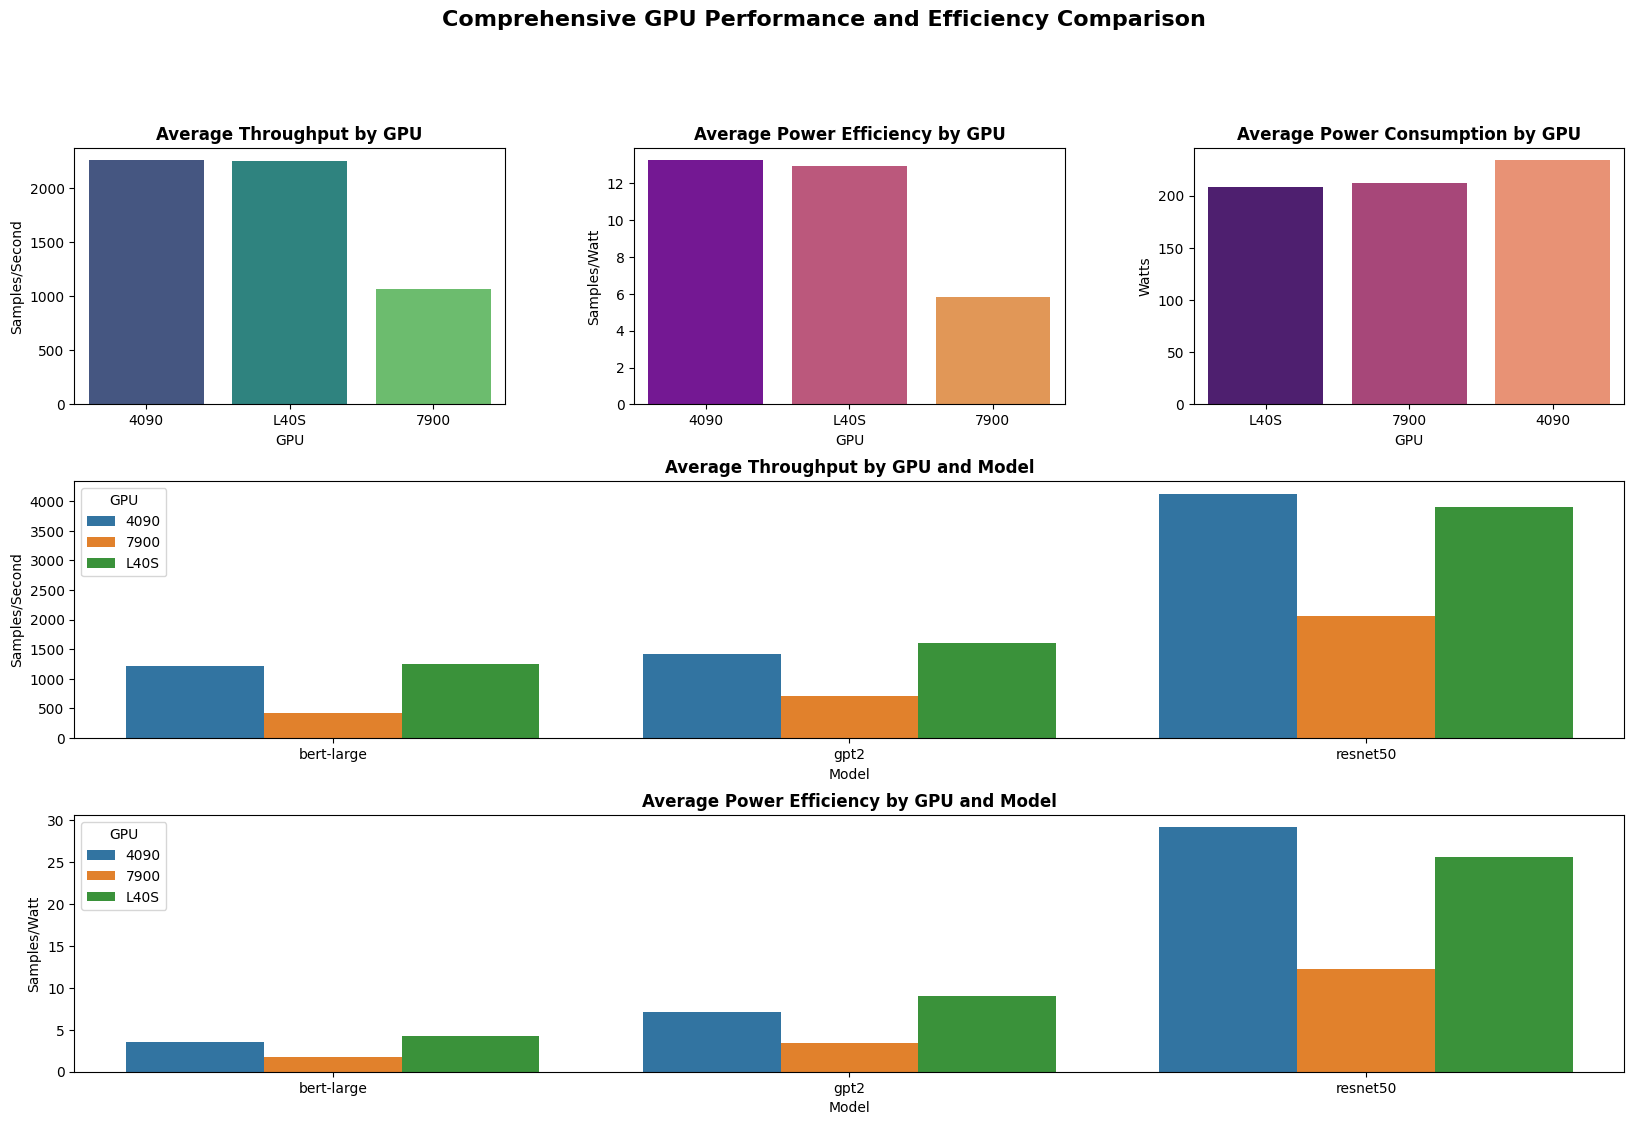

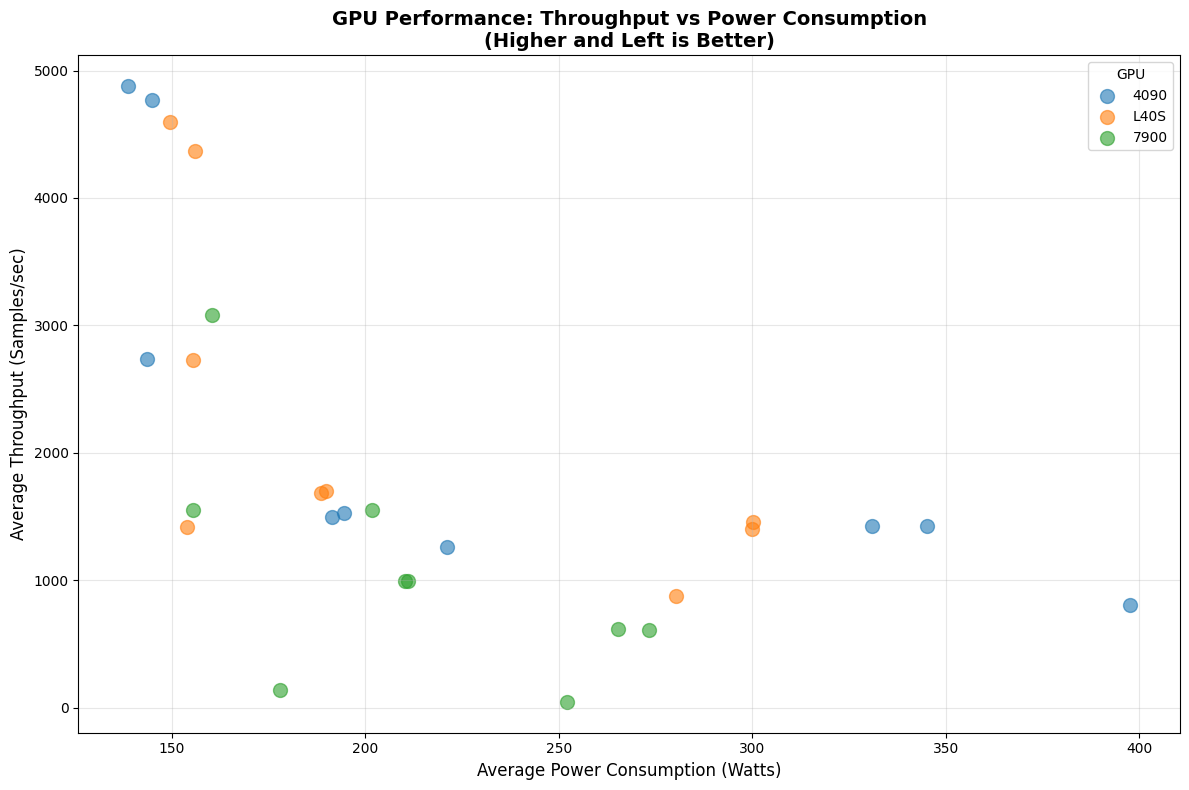


SUMMARY STATISTICS TABLE
      Avg_Throughput  Avg_Power_Watts  Avg_Efficiency  Avg_Memory_MB
GPU                                                                 
4090         2259.04           234.29           13.26        1458.04
7900         1066.42           212.00            5.84        1933.93
L40S         2249.17           208.27           12.95        1300.99

GPU AWARDS

🏆 Best Overall Throughput: 4090 (2259.0 samples/sec)
⚡ Best Power Efficiency: 4090 (13.260 samples/watt)
💚 Most Power Efficient: L40S (208.3 watts)



In [14]:
# Comprehensive GPU Performance and Efficiency Comparison
print("="*100)
print("COMPREHENSIVE GPU PERFORMANCE AND EFFICIENCY COMPARISON")
print("="*100)

# Create summary dataframes for each GPU across all models and precisions
gpu_comparison_data = []

for device in df['device'].unique():
    device_data = df[df['device'] == device]
    
    for model in device_data['model'].unique():
        model_data = device_data[device_data['model'] == model]
        
        for precision in model_data['precision'].unique():
            precision_data = model_data[model_data['precision'] == precision]
            
            if not precision_data.empty:
                gpu_comparison_data.append({
                    'GPU': device,
                    'Model': model,
                    'Precision': precision,
                    'Avg_Throughput': precision_data['throughput_samples_per_sec'].mean(),
                    'Avg_Power_Watts': precision_data['gpu_avg_power_watts'].mean(),
                    'Avg_Efficiency': precision_data['avg_samples_per_watt'].mean(),
                    'Avg_Memory_MB': precision_data['peak_memory_mb'].mean(),
                    'Max_Batch_Size': precision_data['batch_size'].max()
                })

gpu_comparison_df = pd.DataFrame(gpu_comparison_data)

# Overall GPU Rankings
print("\n" + "="*100)
print("OVERALL GPU RANKINGS (Averaged Across All Models and Precisions)")
print("="*100)

overall_gpu_stats = gpu_comparison_df.groupby('GPU').agg({
    'Avg_Throughput': 'mean',
    'Avg_Power_Watts': 'mean',
    'Avg_Efficiency': 'mean',
    'Avg_Memory_MB': 'mean'
}).round(2)

print("\n1. THROUGHPUT RANKING (Higher is Better)")
print("-" * 60)
throughput_rank = overall_gpu_stats.sort_values('Avg_Throughput', ascending=False)
for idx, (gpu, row) in enumerate(throughput_rank.iterrows(), 1):
    print(f"{idx}. {gpu}: {row['Avg_Throughput']:.1f} samples/sec")

print("\n2. POWER EFFICIENCY RANKING (Higher is Better)")
print("-" * 60)
efficiency_rank = overall_gpu_stats.sort_values('Avg_Efficiency', ascending=False)
for idx, (gpu, row) in enumerate(efficiency_rank.iterrows(), 1):
    print(f"{idx}. {gpu}: {row['Avg_Efficiency']:.3f} samples/watt (Avg Power: {row['Avg_Power_Watts']:.1f}W)")

print("\n3. POWER CONSUMPTION RANKING (Lower is Better)")
print("-" * 60)
power_rank = overall_gpu_stats.sort_values('Avg_Power_Watts', ascending=True)
for idx, (gpu, row) in enumerate(power_rank.iterrows(), 1):
    print(f"{idx}. {gpu}: {row['Avg_Power_Watts']:.1f} watts")

print("\n4. MEMORY USAGE RANKING (Lower is Better)")
print("-" * 60)
memory_rank = overall_gpu_stats.sort_values('Avg_Memory_MB', ascending=True)
for idx, (gpu, row) in enumerate(memory_rank.iterrows(), 1):
    print(f"{idx}. {gpu}: {row['Avg_Memory_MB']:.1f} MB")

# Best GPU for each model
print("\n" + "="*100)
print("BEST GPU FOR EACH MODEL (by Efficiency)")
print("="*100)

for model in gpu_comparison_df['Model'].unique():
    print(f"\n{model.upper()}:")
    model_best = gpu_comparison_df[gpu_comparison_df['Model'] == model].groupby('GPU').agg({
        'Avg_Throughput': 'mean',
        'Avg_Efficiency': 'mean',
        'Avg_Power_Watts': 'mean'
    }).sort_values('Avg_Efficiency', ascending=False)
    
    for idx, (gpu, row) in enumerate(model_best.iterrows(), 1):
        print(f"  {idx}. {gpu}: {row['Avg_Efficiency']:.3f} samples/watt "
              f"({row['Avg_Throughput']:.1f} samples/sec @ {row['Avg_Power_Watts']:.1f}W)")

# Precision-specific GPU comparison
print("\n" + "="*100)
print("GPU COMPARISON BY PRECISION TYPE")
print("="*100)

for precision in ['fp32', 'fp16', 'bf16']:
    print(f"\n{precision.upper()} PRECISION:")
    print("-" * 80)
    
    precision_stats = gpu_comparison_df[gpu_comparison_df['Precision'] == precision].groupby('GPU').agg({
        'Avg_Throughput': 'mean',
        'Avg_Power_Watts': 'mean',
        'Avg_Efficiency': 'mean'
    }).sort_values('Avg_Efficiency', ascending=False)
    
    print(f"{'Rank':<6} {'GPU':<10} {'Throughput':<20} {'Power':<15} {'Efficiency':<15}")
    print(f"{'':6} {'':10} {'(samples/sec)':<20} {'(watts)':<15} {'(samp/watt)':<15}")
    print("-" * 80)
    
    for idx, (gpu, row) in enumerate(precision_stats.iterrows(), 1):
        print(f"{idx:<6} {gpu:<10} {row['Avg_Throughput']:<20.1f} {row['Avg_Power_Watts']:<15.1f} {row['Avg_Efficiency']:<15.3f}")

# Create comprehensive visualization
fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# 1. Overall throughput comparison
ax1 = fig.add_subplot(gs[0, 0])
overall_throughput = gpu_comparison_df.groupby('GPU')['Avg_Throughput'].mean().sort_values(ascending=False)
sns.barplot(x=overall_throughput.index, y=overall_throughput.values, ax=ax1, palette='viridis')
ax1.set_title('Average Throughput by GPU', fontweight='bold', fontsize=12)
ax1.set_ylabel('Samples/Second')
ax1.set_xlabel('GPU')

# 2. Overall efficiency comparison
ax2 = fig.add_subplot(gs[0, 1])
overall_efficiency = gpu_comparison_df.groupby('GPU')['Avg_Efficiency'].mean().sort_values(ascending=False)
sns.barplot(x=overall_efficiency.index, y=overall_efficiency.values, ax=ax2, palette='plasma')
ax2.set_title('Average Power Efficiency by GPU', fontweight='bold', fontsize=12)
ax2.set_ylabel('Samples/Watt')
ax2.set_xlabel('GPU')

# 3. Overall power consumption
ax3 = fig.add_subplot(gs[0, 2])
overall_power = gpu_comparison_df.groupby('GPU')['Avg_Power_Watts'].mean().sort_values(ascending=True)
sns.barplot(x=overall_power.index, y=overall_power.values, ax=ax3, palette='magma')
ax3.set_title('Average Power Consumption by GPU', fontweight='bold', fontsize=12)
ax3.set_ylabel('Watts')
ax3.set_xlabel('GPU')

# 4. Throughput by model
ax4 = fig.add_subplot(gs[1, :])
model_throughput = gpu_comparison_df.groupby(['GPU', 'Model'])['Avg_Throughput'].mean().reset_index()
sns.barplot(data=model_throughput, x='Model', y='Avg_Throughput', hue='GPU', ax=ax4)
ax4.set_title('Average Throughput by GPU and Model', fontweight='bold', fontsize=12)
ax4.set_ylabel('Samples/Second')
ax4.legend(title='GPU')

# 5. Efficiency by model
ax5 = fig.add_subplot(gs[2, :])
model_efficiency = gpu_comparison_df.groupby(['GPU', 'Model'])['Avg_Efficiency'].mean().reset_index()
sns.barplot(data=model_efficiency, x='Model', y='Avg_Efficiency', hue='GPU', ax=ax5)
ax5.set_title('Average Power Efficiency by GPU and Model', fontweight='bold', fontsize=12)
ax5.set_ylabel('Samples/Watt')
ax5.legend(title='GPU')

plt.suptitle('Comprehensive GPU Performance and Efficiency Comparison', fontsize=16, fontweight='bold', y=0.995)
plt.show()

# Efficiency vs Throughput scatter plot
fig, ax = plt.subplots(figsize=(12, 8))
for gpu in gpu_comparison_df['GPU'].unique():
    gpu_data = gpu_comparison_df[gpu_comparison_df['GPU'] == gpu]
    ax.scatter(gpu_data['Avg_Power_Watts'], gpu_data['Avg_Throughput'], 
              label=gpu, s=100, alpha=0.6)

ax.set_xlabel('Average Power Consumption (Watts)', fontsize=12)
ax.set_ylabel('Average Throughput (Samples/sec)', fontsize=12)
ax.set_title('GPU Performance: Throughput vs Power Consumption\n(Higher and Left is Better)', 
            fontsize=14, fontweight='bold')
ax.legend(title='GPU')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Summary table
print("\n" + "="*100)
print("SUMMARY STATISTICS TABLE")
print("="*100)
print(overall_gpu_stats.to_string())

# Winner categories
print("\n" + "="*100)
print("GPU AWARDS")
print("="*100)
best_throughput = overall_gpu_stats['Avg_Throughput'].idxmax()
best_efficiency = overall_gpu_stats['Avg_Efficiency'].idxmax()
best_power = overall_gpu_stats['Avg_Power_Watts'].idxmin()

print(f"\n🏆 Best Overall Throughput: {best_throughput} ({overall_gpu_stats.loc[best_throughput, 'Avg_Throughput']:.1f} samples/sec)")
print(f"⚡ Best Power Efficiency: {best_efficiency} ({overall_gpu_stats.loc[best_efficiency, 'Avg_Efficiency']:.3f} samples/watt)")
print(f"💚 Most Power Efficient: {best_power} ({overall_gpu_stats.loc[best_power, 'Avg_Power_Watts']:.1f} watts)")

print("\n" + "="*100)